In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style for publication/thesis level
sns.set_theme(style="whitegrid")

# 1. Define the absolute path
# Note: Check your directory. Depending on the final routine version, 
# the file might be named 'metrics_ExpA_Geometry.parquet' instead of 'benchmark_metrics.parquet'
file_path = r"C:\Users\Matias\Documents\Tesis\Vision-Aided-Beamformer\tests\dataset_out\Exp_A\benchmark_metrics.parquet" 

try:
    # Load the Parquet file into memory
    df = pd.read_parquet(file_path)
    
    # 2. General Summary
    print("="*50)
    print(f"TOTAL EXPERIMENTS RUN (ROWS): {len(df)}")
    print("="*50)
    
    # 3. Inspect Grid Variables (Verify all parameters were evaluated)
    print("\n[+] EXPLORED CONFIGURATION VARIABLES:")
    config_cols = ['rt60', 'M', 'N_interferences', 'use_wpe', 'processor']
    for col in config_cols:
        if col in df.columns:
            # Display unique values to ensure the grid search covered everything
            print(f"  - {col}: {df[col].unique().tolist()}")
            
    # 4. Categorize and Inspect Available Metrics
    print("\n[+] SAVED METRICS (Extracted Columns):")
    deltas = [c for c in df.columns if 'Delta_tot_tot_tot_tot_' in c]
    bases = [c for c in df.columns if 'base_' in c]
    procs = [c for c in df.columns if 'proc_' in c]
    
    print(f"  - Baseline Metrics: {bases}")
    print(f"  - Processed Metrics: {procs}")
    print(f"  - Deltas (Improvements): {deltas}")
    
    # 5. Null (NaN) Detection Report
    # Extremely important for DSP evaluation to catch diverging algorithms
    print("\n[+] ALGORITHM FAILURE REPORT (NaN values in Deltas):")
    nulls = df[deltas].isna().sum()
    if nulls.sum() == 0:
        print("  - Excellent! No null values found. All metrics computed successfully.")
    else:
        print("  - Warning: Missing values found in the following metrics:")
        print(nulls[nulls > 0])

    # 6. Data Preview
    print("\n[+] DATASET PREVIEW (First 5 rows):")
    display(df.head())
    
except FileNotFoundError:
    print(f"ERROR: File not found at path:\n{file_path}")
    print("Please verify the exact file name in your Windows Explorer.")
display(df.head())


TOTAL EXPERIMENTS RUN (ROWS): 512

[+] EXPLORED CONFIGURATION VARIABLES:
  - rt60: [0.0, 0.3, 0.6, 0.9]
  - M: [4, 6, 9, 12]
  - N_interferences: [1, 2, 3, 4]
  - use_wpe: [False, True]
  - processor: ['DS', 'MVDR_Oracle', 'MVDR_SPP', 'MPDR']

[+] SAVED METRICS (Extracted Columns):
  - Baseline Metrics: ['base_STOI', 'base_PESQ', 'base_CD', 'base_SDR', 'base_SIR', 'base_SAR']
  - Processed Metrics: ['proc_STOI', 'proc_PESQ', 'proc_CD', 'proc_SDR', 'proc_SIR', 'proc_SAR']
  - Deltas (Improvements): ['Delta_wpe_STOI', 'Delta_wpe_PESQ', 'Delta_wpe_CD', 'Delta_wpe_SDR', 'Delta_wpe_SIR', 'Delta_wpe_SAR', 'Delta_bf_STOI', 'Delta_bf_PESQ', 'Delta_bf_CD', 'Delta_bf_SDR', 'Delta_bf_SIR', 'Delta_bf_SAR', 'Delta_tot_STOI', 'Delta_tot_PESQ', 'Delta_tot_CD', 'Delta_tot_SDR', 'Delta_tot_SIR', 'Delta_tot_SAR']

[+] ALGORITHM FAILURE REPORT (NaN values in Deltas):
  - Excellent! No null values found. All metrics computed successfully.

[+] DATASET PREVIEW (First 5 rows):


,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,exec_time_s,...,Delta_bf_CD,Delta_bf_SDR,Delta_bf_SIR,Delta_bf_SAR,Delta_tot_STOI,Delta_tot_PESQ,Delta_tot_CD,Delta_tot_SDR,Delta_tot_SIR,Delta_tot_SAR
0,DS,0.0,4,1,0.0,0,0,0,False,0.223893,...,-1.068704,2.238761,2.238970,-12.867511,0.062257,0.064146,-1.068704,2.238761,2.238970,-12.867511
1,MVDR_Oracle,0.0,4,1,0.0,0,0,0,False,0.941995,...,-2.940178,21.100403,22.644113,-33.618272,0.184277,1.248174,-2.940178,21.100403,22.644113,-33.618272
2,MVDR_SPP,0.0,4,1,0.0,0,0,0,False,1.196144,...,-2.776532,13.732418,14.399151,-37.640301,0.170351,0.598764,-2.776532,13.732418,14.399151,-37.640301
3,MPDR,0.0,4,1,0.0,0,0,0,False,0.962456,...,-2.634813,17.617913,18.960370,-36.560698,0.170684,0.894431,-2.634813,17.617913,18.960370,-36.560698
4,DS,0.0,4,1,0.0,0,0,0,True,0.226548,...,-0.922839,2.237786,2.293669,-0.293497,0.050438,0.033271,-0.470333,1.313166,1.503184,-42.825185


,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,exec_time_s,...,Delta_bf_CD,Delta_bf_SDR,Delta_bf_SIR,Delta_bf_SAR,Delta_tot_STOI,Delta_tot_PESQ,Delta_tot_CD,Delta_tot_SDR,Delta_tot_SIR,Delta_tot_SAR
0,DS,0.0,4,1,0.0,0,0,0,False,0.223893,...,-1.068704,2.238761,2.238970,-12.867511,0.062257,0.064146,-1.068704,2.238761,2.238970,-12.867511
1,MVDR_Oracle,0.0,4,1,0.0,0,0,0,False,0.941995,...,-2.940178,21.100403,22.644113,-33.618272,0.184277,1.248174,-2.940178,21.100403,22.644113,-33.618272
2,MVDR_SPP,0.0,4,1,0.0,0,0,0,False,1.196144,...,-2.776532,13.732418,14.399151,-37.640301,0.170351,0.598764,-2.776532,13.732418,14.399151,-37.640301
3,MPDR,0.0,4,1,0.0,0,0,0,False,0.962456,...,-2.634813,17.617913,18.960370,-36.560698,0.170684,0.894431,-2.634813,17.617913,18.960370,-36.560698
4,DS,0.0,4,1,0.0,0,0,0,True,0.226548,...,-0.922839,2.237786,2.293669,-0.293497,0.050438,0.033271,-0.470333,1.313166,1.503184,-42.825185


<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Matias\AppData\Local\Temp\ipykernel_2940\1841429907.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Improvement in PESQ ($\Delta$ PESQ)', fontsize=12)


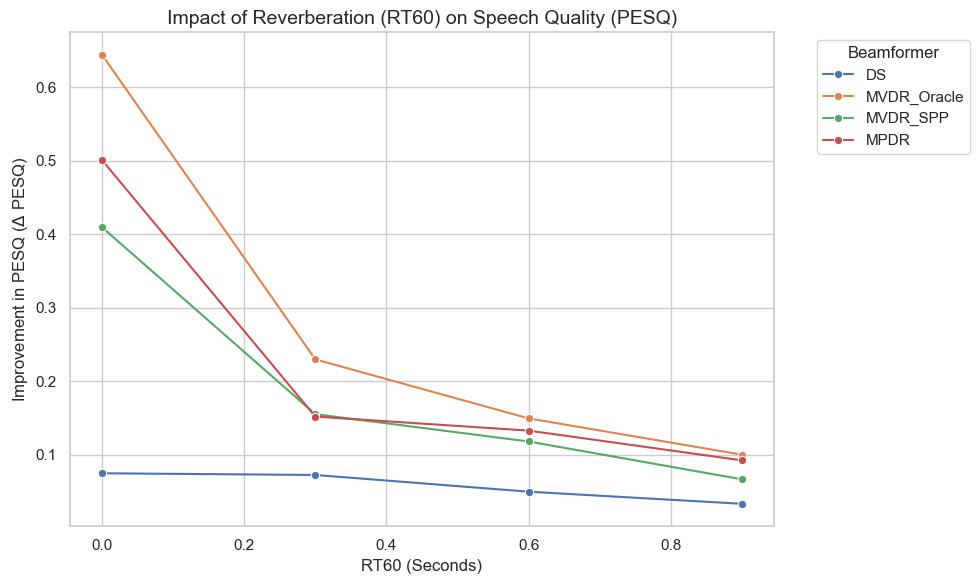

In [3]:
# Create a figure for the RT60 impact analysis
plt.figure(figsize=(10, 6))

# Use a line plot with error bars to show the trend across reverberation times
sns.lineplot(
    data=df, 
    x='rt60', 
    y='Delta_tot_PESQ', 
    hue='processor', 
    marker='o',
    errorbar=None # Set to 'sd' if you want to see the standard deviation variance
)

# Format the plot for thesis quality
plt.title('Impact of Reverberation (RT60) on Speech Quality (PESQ)', fontsize=14)
plt.xlabel('RT60 (Seconds)', fontsize=12)
plt.ylabel('Improvement in PESQ ($\Delta$ PESQ)', fontsize=12)
plt.legend(title='Beamformer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure in high resolution for LaTeX integration
plt.savefig("rt60_impact_pesq.pdf", dpi=300, bbox_inches='tight')
plt.show()

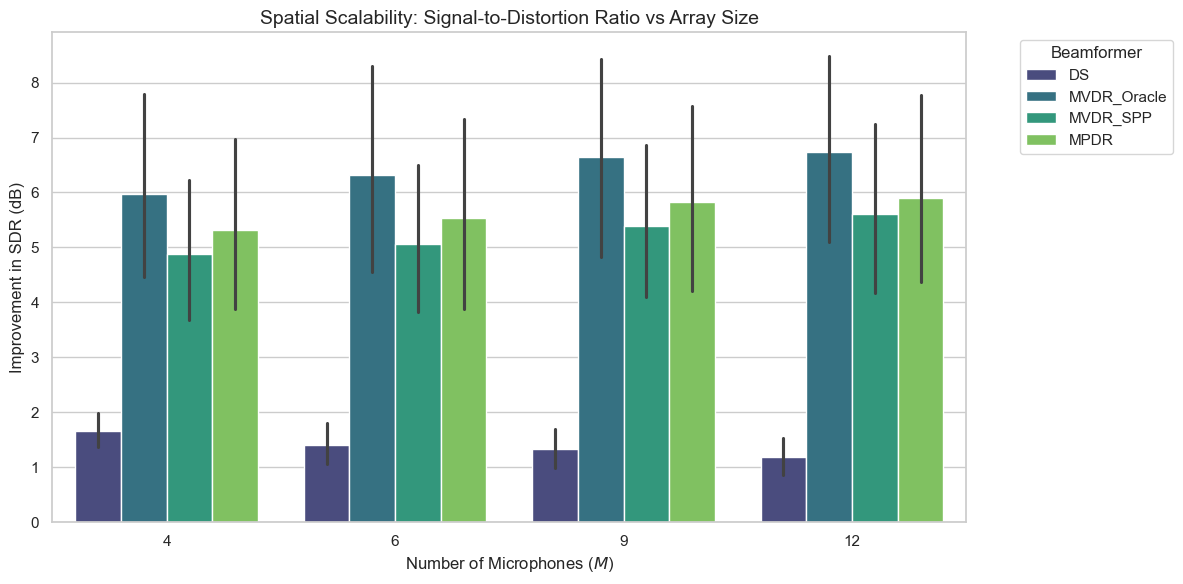

In [4]:
# Create a figure for the microphone array size analysis
plt.figure(figsize=(12, 6))

# Use a bar plot to compare the performance gain as microphones increase
sns.barplot(
    data=df, 
    x='M', 
    y='Delta_tot_SDR', 
    hue='processor',
    palette='viridis'
)

# Format the plot for thesis quality
plt.title('Spatial Scalability: Signal-to-Distortion Ratio vs Array Size', fontsize=14)
plt.xlabel('Number of Microphones ($M$)', fontsize=12)
plt.ylabel('Improvement in SDR (dB)', fontsize=12)
plt.legend(title='Beamformer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure in high resolution
plt.savefig("mic_scalability_sdr.pdf", dpi=300, bbox_inches='tight')
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Matias\AppData\Local\Temp\ipykernel_2940\2642874557.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Improvement in PESQ ($\Delta$ PESQ)', fontsize=12)


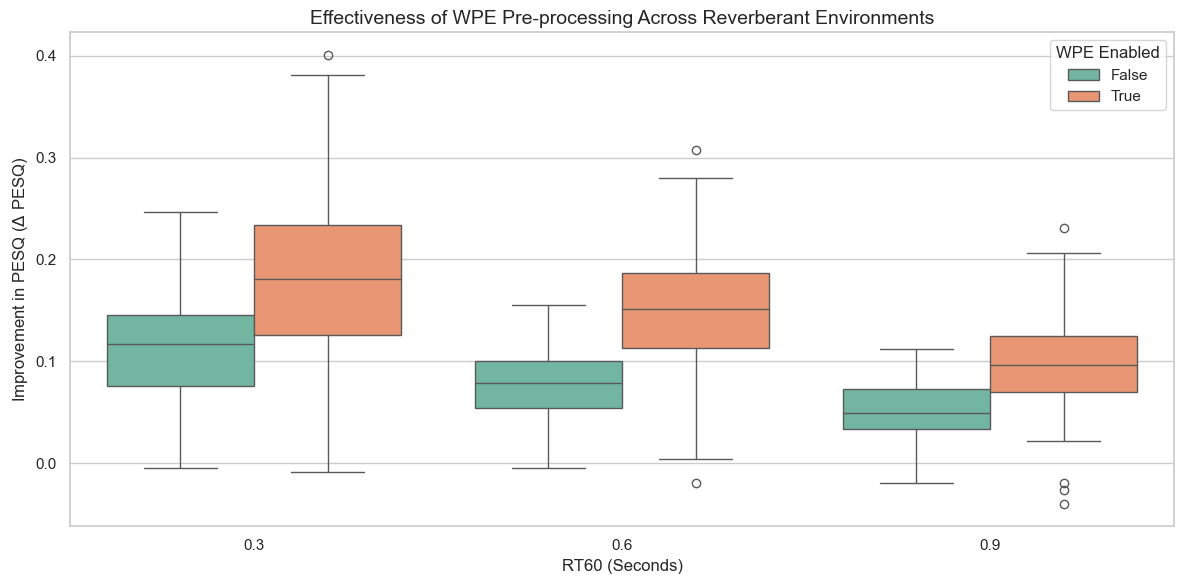

In [6]:
# Filter out the anechoic case since WPE is useless without reverberation
df_reverb = df[df['rt60'] > 0.0]

# Create a figure for the WPE effectiveness analysis
plt.figure(figsize=(12, 6))

# Use a boxplot to see the distribution of improvements with and without WPE
sns.boxplot(
    data=df_reverb, 
    x='rt60', 
    y='Delta_tot_PESQ', 
    hue='use_wpe', 
    palette='Set2'
)

# Format the plot for thesis quality
plt.title('Effectiveness of WPE Pre-processing Across Reverberant Environments', fontsize=14)
plt.xlabel('RT60 (Seconds)', fontsize=12)
plt.ylabel('Improvement in PESQ ($\Delta$ PESQ)', fontsize=12)
plt.legend(title='WPE Enabled')
plt.tight_layout()

# Save the figure in high resolution
plt.savefig("wpe_effectiveness.pdf", dpi=300, bbox_inches='tight')
plt.show()

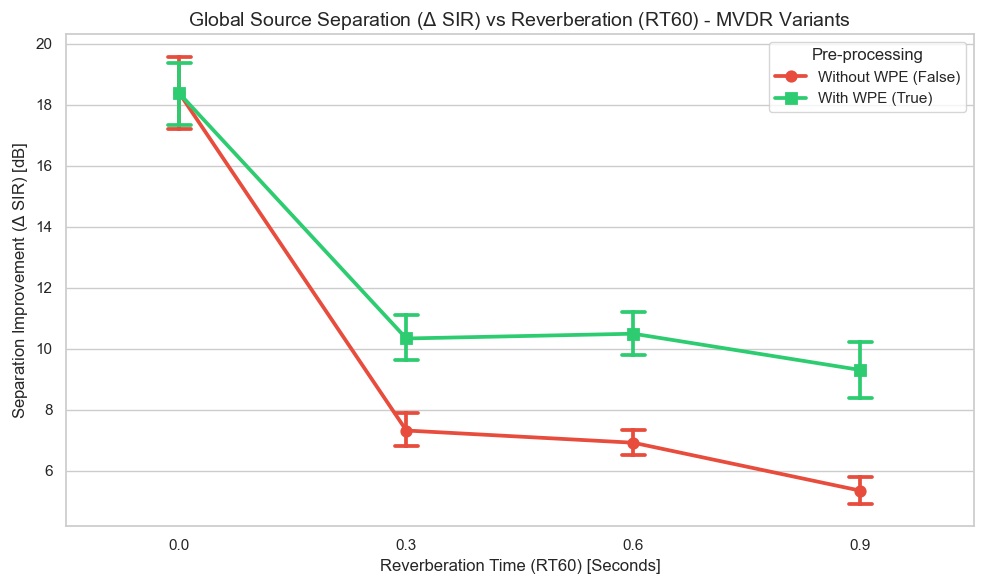

In [7]:
# Filter the dataframe to include only MVDR variants (Oracle, RTF, SPP)
# This uses the 'processor' column defined in your grid search results
df_mvdr = df[df['processor'].str.contains('MVDR', case=False)]

# Create a figure for the global separation trend
plt.figure(figsize=(10, 6))

# Use a pointplot to show the average Delta_SIR with error bars (confidence intervals)
sns.pointplot(
    data=df_mvdr,
    x='rt60',
    y='Delta_tot_SIR',
    hue='use_wpe',
    palette=['#e74c3c', '#2ecc71'], # Red for False (No WPE), Green for True (With WPE)
    markers=['o', 's'],
    capsize=0.1
)

# Format the plot for thesis quality using LaTeX for math notation
plt.title(r'Global Source Separation ($\Delta$ SIR) vs Reverberation (RT60) - MVDR Variants', fontsize=14)
plt.xlabel('Reverberation Time (RT60) [Seconds]', fontsize=12)
plt.ylabel(r'Separation Improvement ($\Delta$ SIR) [dB]', fontsize=12)

# Customize the legend for clarity
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Without WPE (False)', 'With WPE (True)'], title='Pre-processing', loc='best')

plt.tight_layout()
# Save as vector graphic for LaTeX/Word
plt.savefig("global_separation_mvdr_wpe_rt60.pdf", dpi=300, bbox_inches='tight')
plt.show()

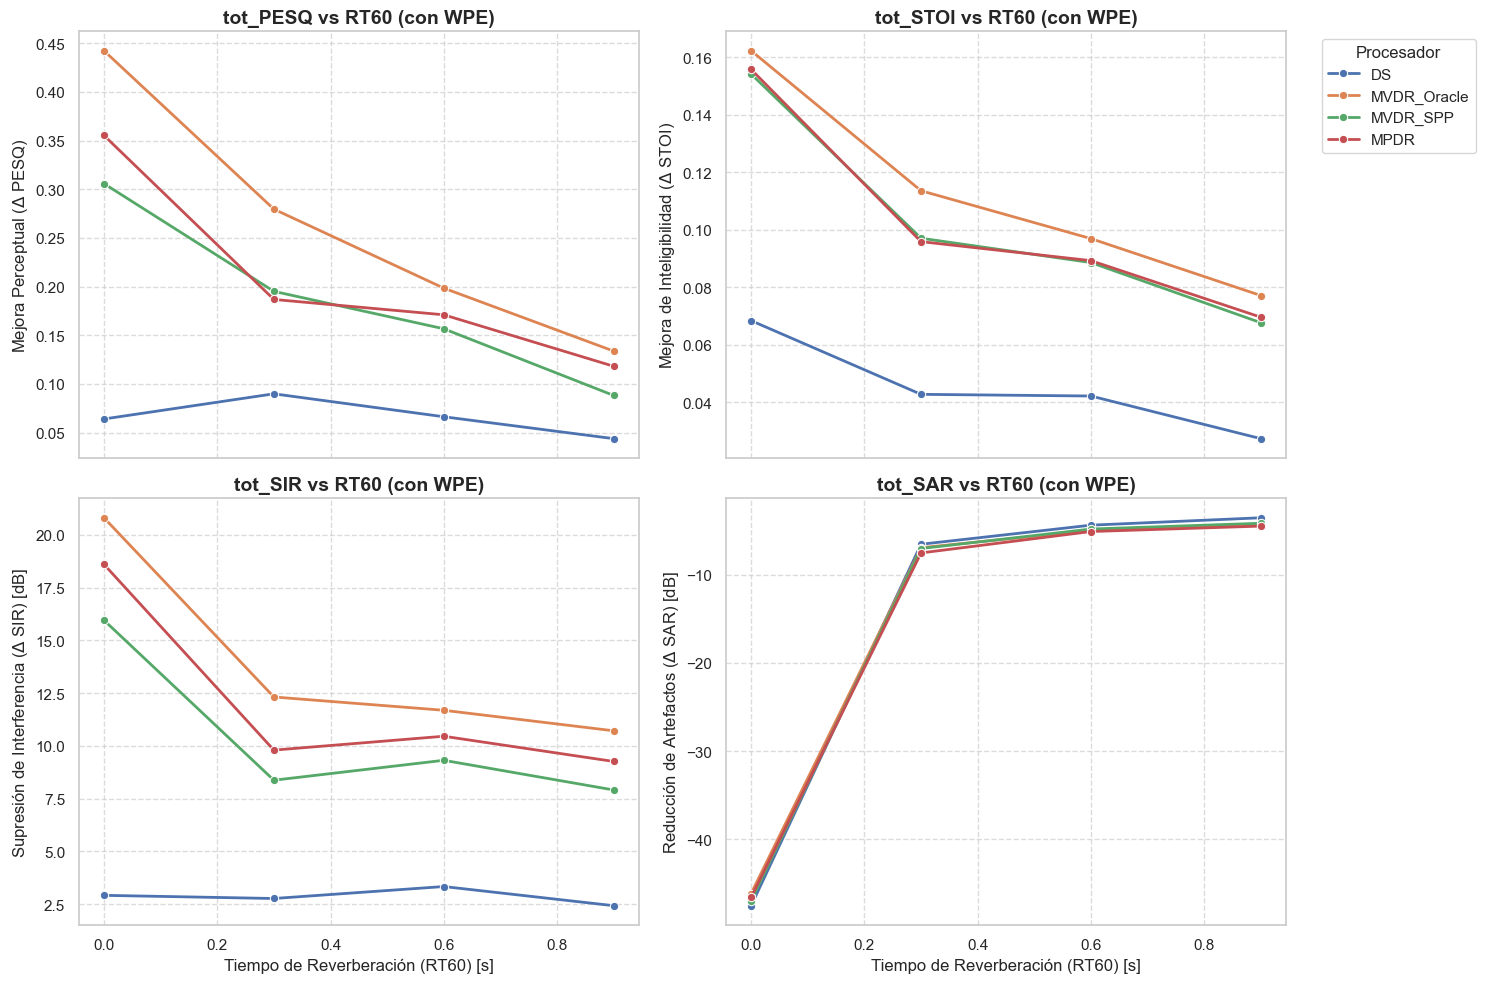

In [8]:
# 1. Filter the dataset to include only cases where WPE was active
df_wpe = df[df['use_wpe'] == True]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flatten to iterate easily

# 3. Define the metrics to plot and their respective Y-axis labels
# Note: Using Delta to show the net improvement of the beamformer over the baseline.
# If you prefer absolute values, change 'Delta_' to 'proc_'
metrics_to_plot = [
    ('Delta_tot_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_tot_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_tot_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_tot_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_wpe,
        x='rt60',
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, # Set to 'sd' if you want to display the standard deviation band
        linewidth=2
    )
    
    # Format individual subplots
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs RT60 (con WPE)', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Only show X-axis label on the bottom row to keep it clean
    if i >= 2:
        axes[i].set_xlabel('Tiempo de Reverberación (RT60) [s]', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    # Add a grid for readability
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Remove individual legends to create a single global legend later
    if i != 1:
        axes[i].get_legend().remove()
    else:
        # Keep the legend only on the top-right plot and move it outside
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# 5. Adjust layout and save the figure
plt.tight_layout()
plt.savefig("metrics_vs_rt60_wpe_enabled.pdf", dpi=300, bbox_inches='tight')
plt.show()

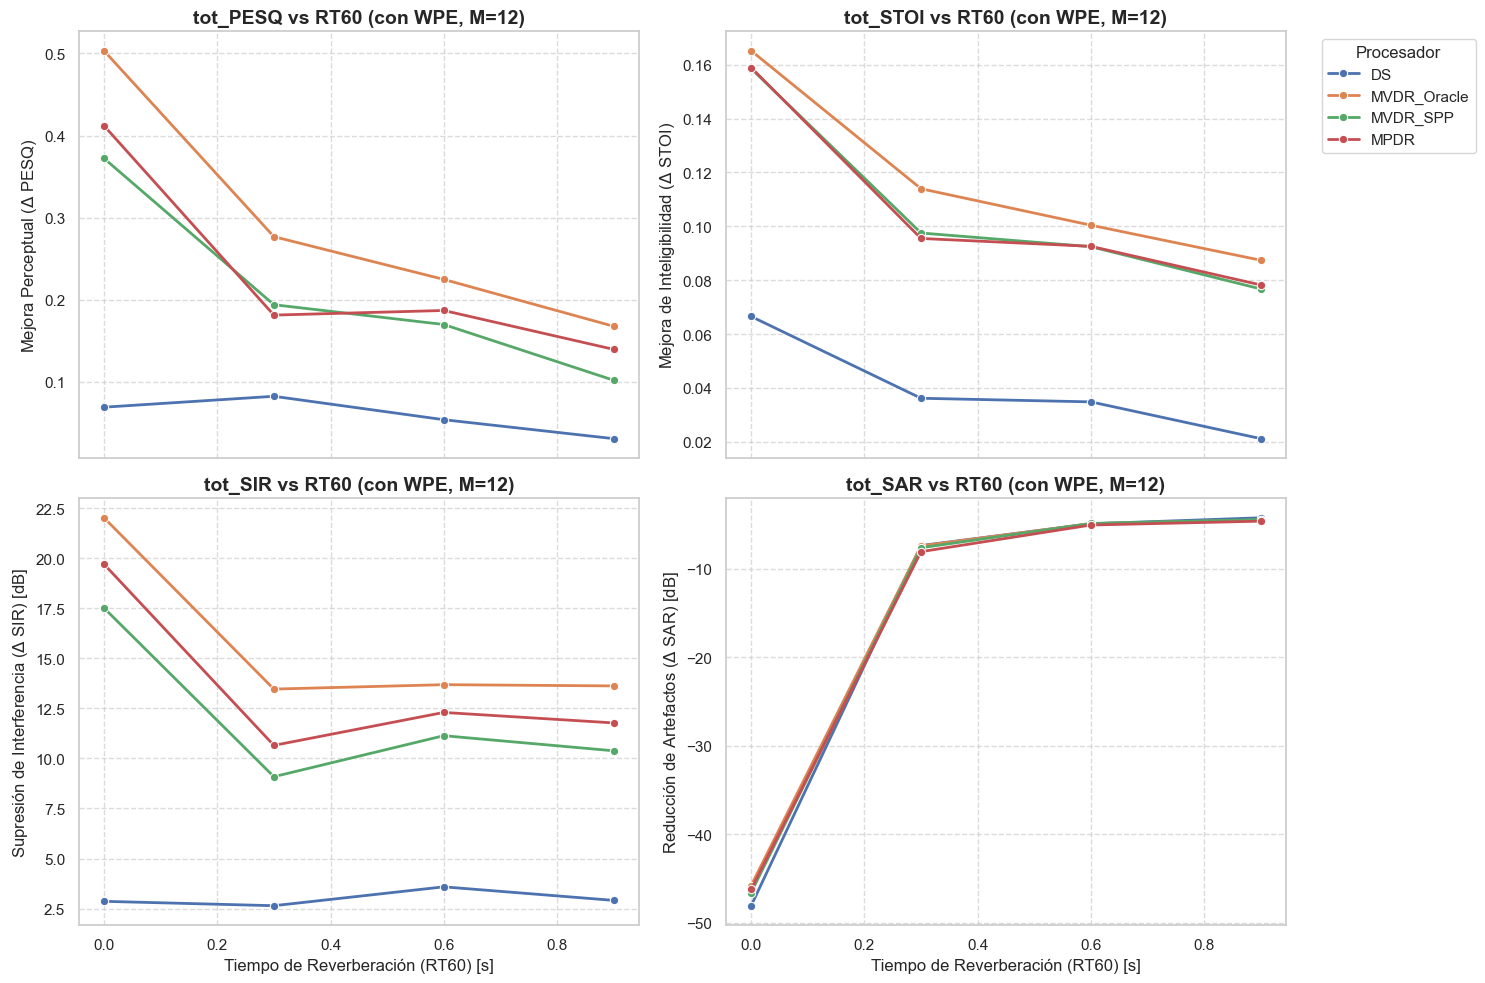

In [9]:
# 1. Filter the dataset to include only cases where WPE was active AND M=12
df_filtered = df[(df['use_wpe'] == True) & (df['M'] == 12)]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flatten to iterate easily

# 3. Define the metrics to plot and their respective Y-axis labels
# Note: Using Delta to show the net improvement of the beamformer over the baseline.
metrics_to_plot = [
    ('Delta_tot_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_tot_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_tot_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_tot_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_filtered,
        x='rt60',
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, # Set to 'sd' if you want to display the standard deviation band
        linewidth=2
    )
    
    # Format individual subplots
    # Added "M=12" to the subplot titles for clarity
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs RT60 (con WPE, M=12)', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Only show X-axis label on the bottom row to keep it clean
    if i >= 2:
        axes[i].set_xlabel('Tiempo de Reverberación (RT60) [s]', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    # Add a grid for readability
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Remove individual legends to create a single global legend later
    if i != 1:
        axes[i].get_legend().remove()
    else:
        # Keep the legend only on the top-right plot and move it outside
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# 5. Adjust layout and save the figure
plt.tight_layout()
plt.savefig("metrics_vs_rt60_wpe_enabled_M12.pdf", dpi=300, bbox_inches='tight')
plt.show()

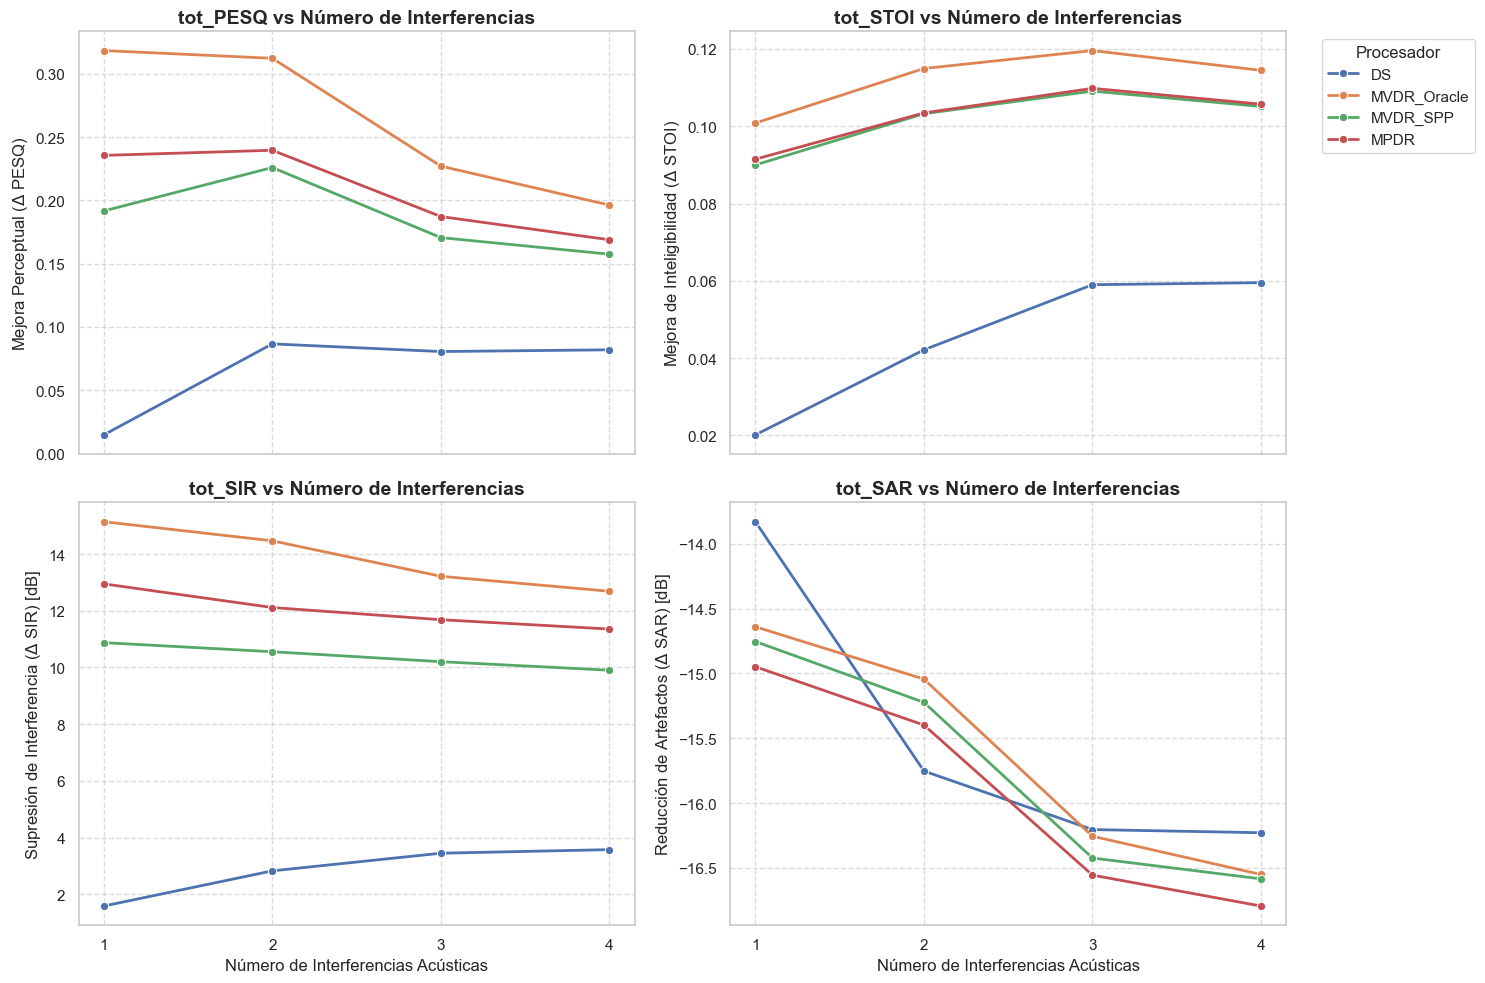

In [10]:
# 1. Filter the dataset to include cases with WPE enabled
# Note: This will average the performance across all RT60 and M configurations. 
# If you want to fix RT60 to a specific value, you can add: & (df['rt60'] == 0.6)
df_interf = df[df['use_wpe'] == True]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 3. Define the metrics to plot and their respective Y-axis labels
metrics_to_plot = [
    ('Delta_tot_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_tot_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_tot_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_tot_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_interf,
        x='N_interferences',
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, # Set to 'sd' if you want to display the standard deviation band
        linewidth=2
    )
    
    # Format individual subplots
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs Número de Interferencias', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Force X-axis ticks to be integers (1, 2, 3, 4)
    axes[i].set_xticks([1, 2, 3, 4])
    
    # Only show X-axis label on the bottom row to keep the layout clean
    if i >= 2:
        axes[i].set_xlabel('Número de Interferencias Acústicas', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    # Add a grid for readability
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Remove individual legends to create a single global legend later
    if i != 1:
        axes[i].get_legend().remove()
    else:
        # Keep the legend only on the top-right plot and move it strictly outside
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# 5. Adjust overall layout and save the figure
plt.tight_layout()
plt.savefig("metrics_vs_interferences_wpe.pdf", dpi=300, bbox_inches='tight')
plt.show()

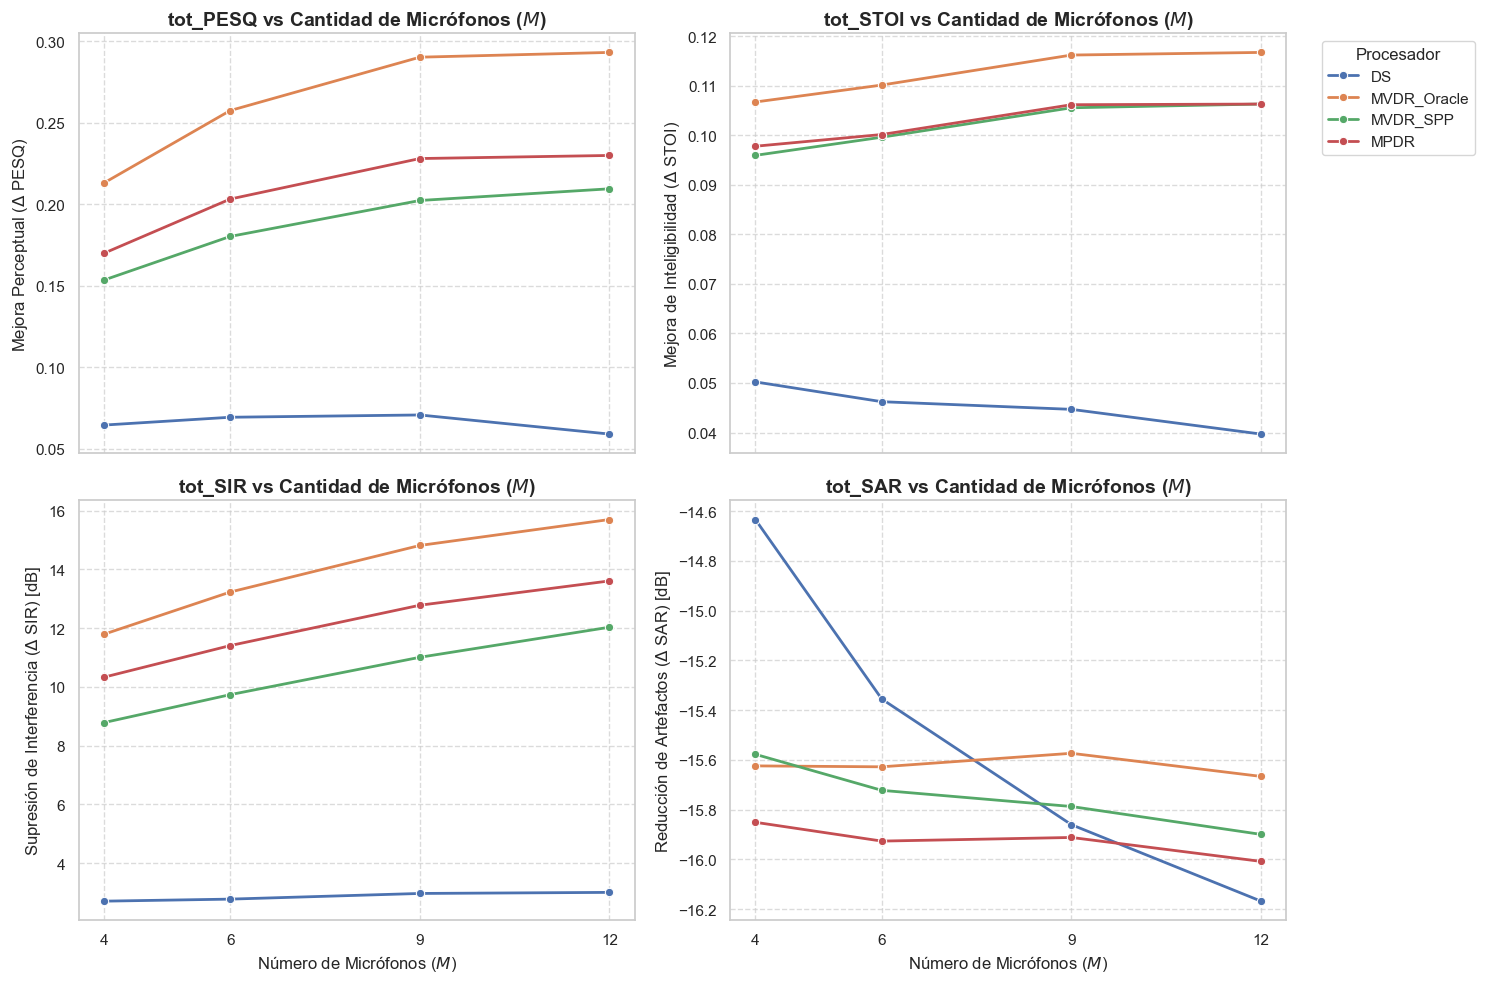

In [12]:
# 1. Filter the dataset to include only cases where WPE was active
df_mics = df[df['use_wpe'] == True]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 3. Define the metrics to plot and their respective Y-axis labels
metrics_to_plot = [
    ('Delta_tot_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_tot_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_tot_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_tot_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_mics,
        x='M',
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, # Set to 'sd' if you want to display the standard deviation band
        linewidth=2
    )
    
    # Format individual subplots
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs Cantidad de Micrófonos ($M$)', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Force X-axis ticks to match the exact values evaluated in the grid
    axes[i].set_xticks([4, 6, 9, 12])
    
    # Only show X-axis label on the bottom row to keep the layout clean
    if i >= 2:
        axes[i].set_xlabel('Número de Micrófonos ($M$)', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    # Add a grid for readability
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Remove individual legends to create a single global legend later
    if i != 1:
        axes[i].get_legend().remove()
    else:
        # Keep the legend only on the top-right plot and move it strictly outside
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# 5. Adjust overall layout and save the figure
plt.tight_layout()
plt.savefig("metrics_vs_microphones_wpe.pdf", dpi=300, bbox_inches='tight')
plt.show()